In [1]:
"""
This is a simple Jupyter notebook for analyzing the measurements taken with the 
spectrum analyser and the BLE receiver to compare actual signal strength (from
spectrum analyser) and RSSI (from BLE receiver). 

The data provided with this notebook was measured in a conducted experiments
simulating two path propagation scenario with a difference between direct and
reflected path of 5 meters. The transmitter and receiver were nRF52840 modules.
Transmitter was set to 8dBm tx power, had an attenuator of 20dB in series, and
was transmitting over all 40 BLE channels (periodicaly switched between legacy 
and extended advertising channels).

Data files:
 - `BLE_receiver.txt` - a text file outputed by the BLE receiver, containing RSSI 
    values for each channel (chan_idx)
 - `Signal_analyser.csv` - semicolon-separated CSV file with a header outputed 
    by the spectrum analyser

You can use this data and code freely, but please give credit to the original 
authors citing following article:
   P.Patronik, A.Jezak, M.Slabicki, M.Nikodem, "Towards more reliable 
   signal strength based indoor localization in Bluetooth Low Energy", 
   21st International Conference on Dependability of Computer Systems 
   (DepCoS-RELCOMEX), 2026, June 29 - July 3, 2026, Brunow, Poland.

"""

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import utils.measurements as measurements

# Add project root (so `utils/` is importable)
sys.path.append(str(Path.cwd() / "utils"))

In [2]:
## Load measurement data
filePath = str(Path.cwd() / "data" )

# From BLE receiver
df_ble = measurements.load_multichannel_rssi_from_file(filePath  + "/BLE_receiver.txt")
df_ble = measurements.add_frequency_column(df_ble)  # Add frequency column based on chan_idx

# From signal analyser
df_waterfall = measurements.load_waterfal_from_file(filePath + "/Signal_analyser.csv")
df_waterfall_avg = measurements.average_waterfall_by_frequency(df_waterfall, threshold=-60) # Average waterfall data along time (frames), i.e. remove 3rd dimension


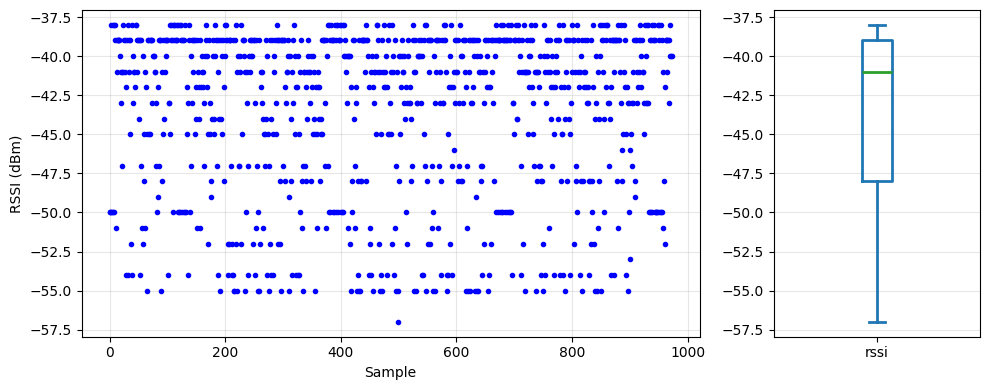

In [3]:
## Plot RSSI measured by BLE receiver without channel information
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})

axes[0].plot(df_ble['rssi'], marker='.', linestyle='', color='blue')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('RSSI (dBm)')
axes[0].grid(True, alpha=0.3)

df_ble['rssi'].plot(kind='box', ax=axes[1])
axes[1].grid(True, alpha=0.3, axis='y')
for line in axes[1].lines:
    line.set_linewidth(2)
for patch in axes[1].artists:
    patch.set_linewidth(2)

plt.tight_layout()

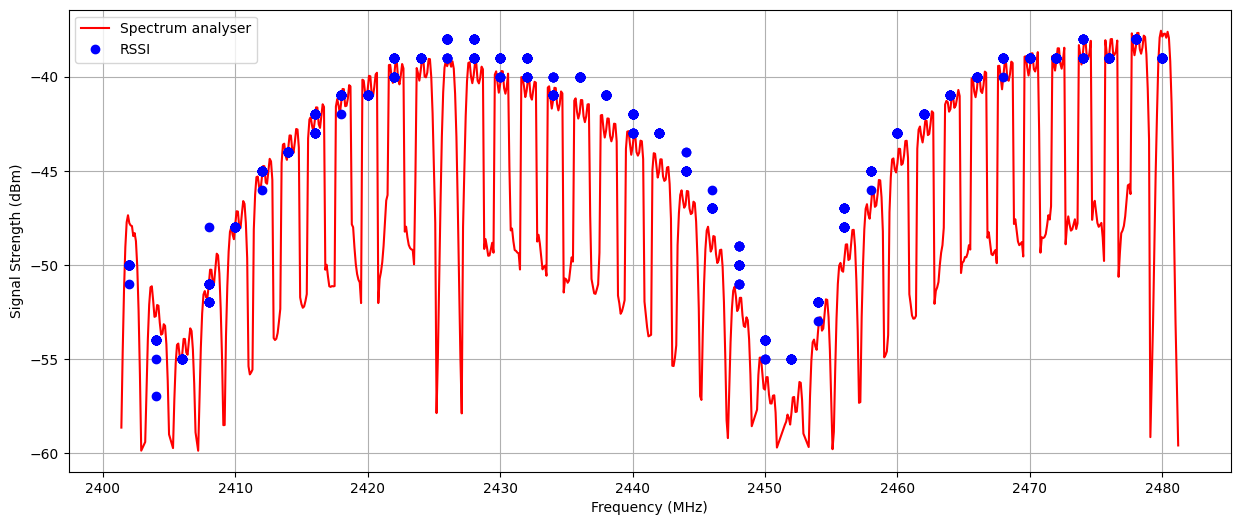

In [4]:
## Plot RSSI measured by BLE receiver and signal strength measured by spectrum analyser
plt.figure(figsize=(15, 6)) 
plt.plot(df_waterfall_avg['Frequency'] / 1e6, df_waterfall_avg['AvgSignalStrength'], marker='', linestyle='-', color='red')
plt.plot(df_ble['Frequency'], df_ble['rssi'], marker='o', linestyle='', color='blue')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Signal Strength (dBm)')
plt.grid()
plt.legend(['Spectrum analyser', 'RSSI'])
